In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [3]:
p1g = pd.read_csv(Path(os.getcwd()).parent / "datos" / "brutos" / "Planta1_Generacion.csv")
p1s = pd.read_csv(Path(os.getcwd()).parent / "datos" / "brutos" / "Planta1_Sensores.csv")
p2g = pd.read_csv(Path(os.getcwd()).parent / "datos" / "brutos" / "Planta2_Generacion.csv")
p2s = pd.read_csv(Path(os.getcwd()).parent / "datos" / "brutos" / "Planta2_Sensores.csv")

In [28]:
p1g.head()

,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
0,2020-05-15,P1,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,2020-05-15,P1,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,2020-05-15,P1,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,2020-05-15,P1,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,2020-05-15,P1,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [16]:
p1g["fecha_hora"] = pd.to_datetime(p1g["fecha_hora"], format="%d-%m-%Y %H:%M", dayfirst=True)

In [17]:
# Verificar el tipo de dato de la columna "fecha_hora"
print(p1g["fecha_hora"].dtype)

datetime64[us]


In [18]:
#  sacame los datos de la columna fecha_hora entre las 12.00 y las 13.00 horas
p1g_12_13 = p1g[(p1g["fecha_hora"].dt.hour >= 12) & (p1g["fecha_hora"].dt.hour < 13)]
p1g_12_13.head()

,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
1036,2020-05-15 12:00:00,4135001,1BY6WEcLGh8j5v7,8232.500000,805.187500,2382.875000,6261941.875
1037,2020-05-15 12:00:00,4135001,1IF53ai7Xc0U56Y,7013.142857,686.114286,2752.428571,6186397.429
1038,2020-05-15 12:00:00,4135001,3PZuoBAID5Wc2HD,6402.571429,626.871429,2676.285714,6990435.286
1039,2020-05-15 12:00:00,4135001,7JYdWkrLSPkdwr4,6910.714286,676.542857,2612.857143,7605572.857
1040,2020-05-15 12:00:00,4135001,McdE0feGgRqW7Ca,6201.714286,607.442857,2888.714286,7161852.714


In [25]:
p1g.info()

<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fecha_hora          68778 non-null  datetime64[us]
 1   id_planta           68778 non-null  int64         
 2   id_inversor         68778 non-null  object        
 3   potencia_dc_kw      68778 non-null  float64       
 4   potencia_ac_kw      68778 non-null  float64       
 5   energia_diaria_kwh  68778 non-null  float64       
 6   energia_total_kwh   68778 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(1), object(1)
memory usage: 3.7+ MB


In [24]:
# Cambiar el tipo dato id_inversor de str a object
p1g["id_inversor"] = p1g["id_inversor"].astype("object")

In [29]:
p1g["id_planta"] = p1g["id_planta"].replace(4135001, "p1" )

In [30]:
p1g.describe().T

,count,mean,min,25%,50%,75%,max,std
fecha_hora,68778,2020-06-01 08:02:49.458257,2020-05-15 00:00:00,2020-05-24 00:45:00,2020-06-01 14:30:00,2020-06-09 20:00:00,2020-06-17 23:45:00,NaN
potencia_dc_kw,68778.0,3147.426211,0.0,0.0,429.0,6366.964286,14471.125,4036.457169
potencia_ac_kw,68778.0,307.802752,0.0,0.0,41.49375,623.61875,1410.95,394.396439
energia_diaria_kwh,68778.0,3295.968737,0.0,0.0,2658.714286,6274.0,9163.0,3145.178309
energia_total_kwh,68778.0,6978711.760671,6183645.0,6512002.53575,7146685.0,7268705.90625,7846821.0,416271.982856


<Axes: >

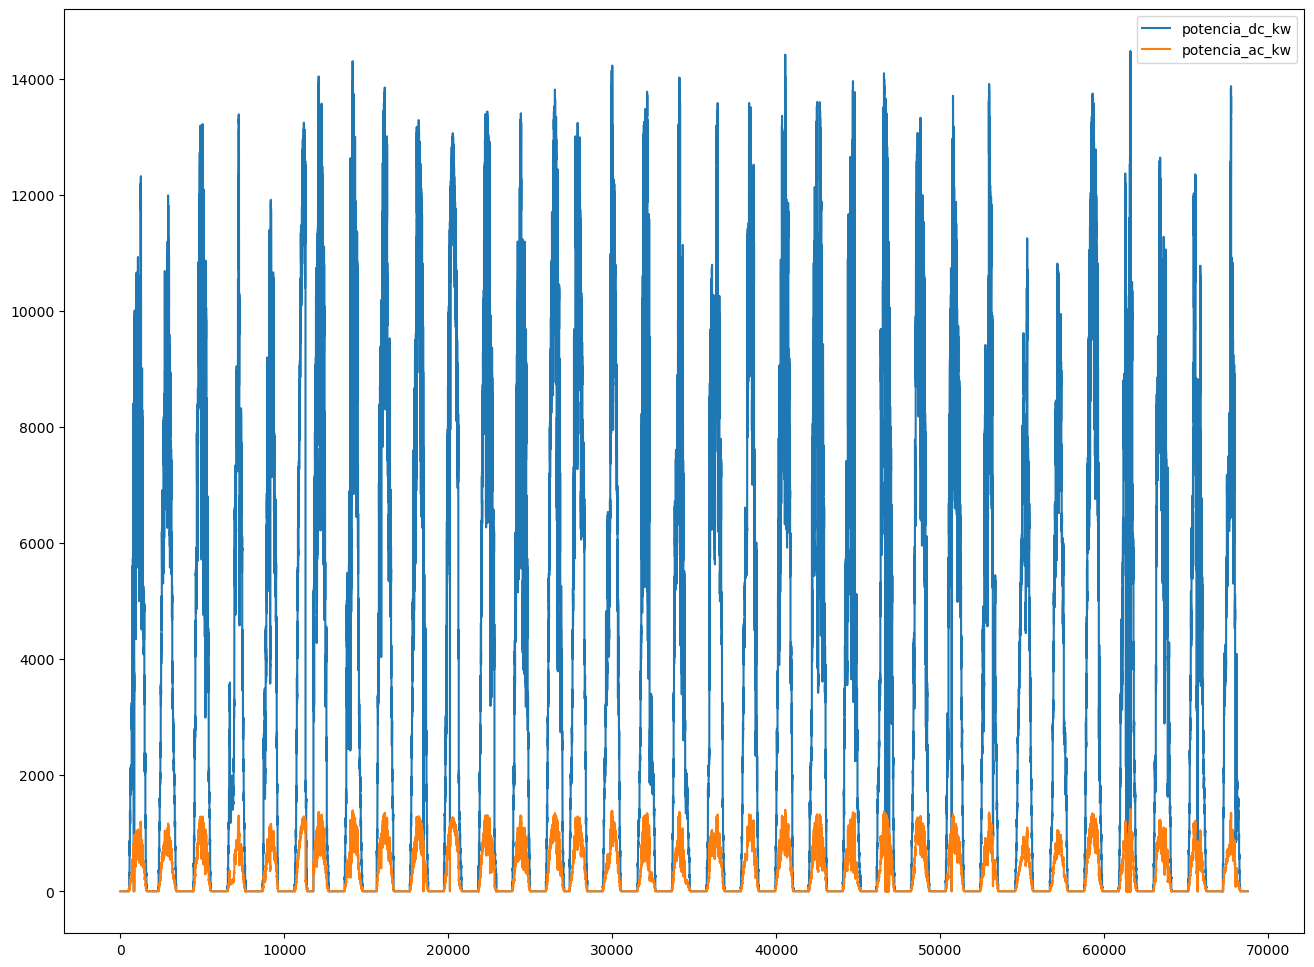

In [34]:
p1g[['potencia_dc_kw', 'potencia_ac_kw']].plot(figsize=(16, 12))